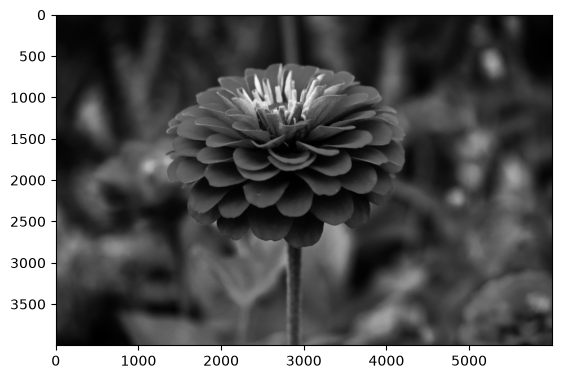

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('img.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray, cmap="gray")
plt.show()

# 1.1 Зашумить изображение при помощи шума Гаусса

In [5]:
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,  16,   0, ..., 150,  56,   0],
       [ 86,   0, 238, ...,   0,   0,  36],
       [ 39, 106,   0, ...,   0, 194,   0],
       ...,
       [  0,   0,  36, ...,   0,  35, 139],
       [  0,   0,   0, ...,   0, 106,   0],
       [102,   0,   0, ...,   0,  67,   0]],
      shape=(4000, 6000), dtype=uint8)

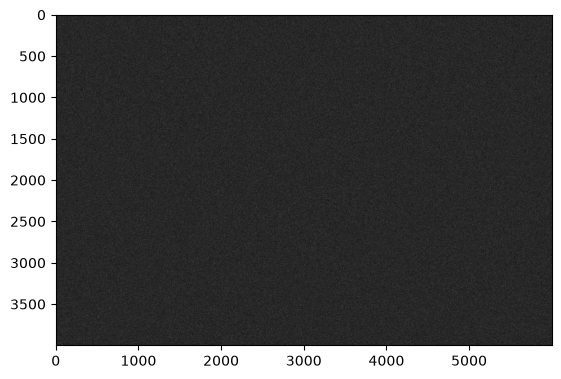

In [6]:
plt.imshow(noise_gauss, cmap="gray")

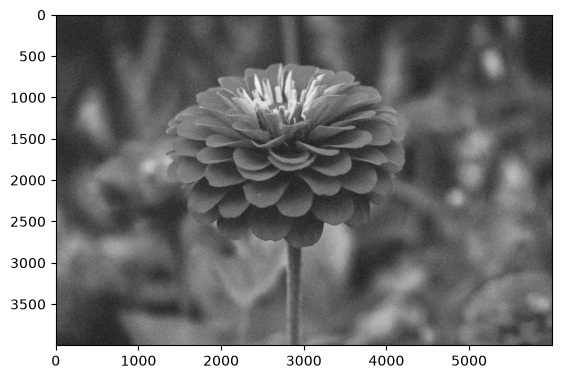

In [8]:
image_noise_gauss = cv2.add(image_gray, noise_gauss)

plt.imshow(image_noise_gauss, cmap="gray")

# 1.2 Зашумить изображение при помощи постоянного шума

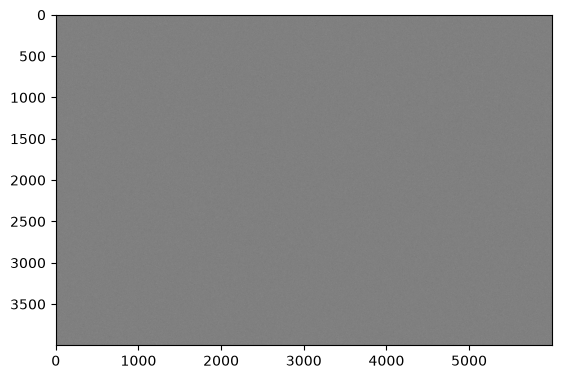

In [7]:
noise = np.random.randint(0, 101, size = (image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

bg_image = np.ones(image_gray.shape, np.uint8) * 128

bg_image[zeros_pixel] = 0
bg_image[ones_pixel] = 255

plt.imshow(bg_image, cmap="gray")

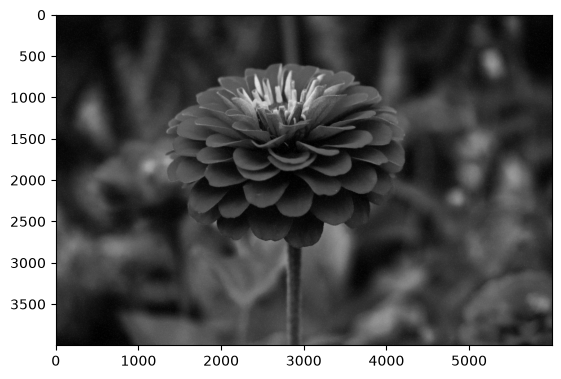

In [9]:
import copy
image_sp = copy.deepcopy(image_gray)
image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255

plt.imshow(image_sp, cmap="gray")

# 2.1 Оценка исходного зашумления

In [10]:
from skimage.metrics import structural_similarity, mean_squared_error

mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim_gauss, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print(mse_gauss, ssim_gauss)

mse_sp = mean_squared_error(image_gray, image_sp)
(ssim_sp, diff) = structural_similarity(image_gray, image_sp, full=True)
print(mse_sp, ssim_sp)

4498.495616958333 0.025890101157439005
446.0348984583333 0.5494820700023026


# 2.2 Медианный фильтр с разными параметрами

In [15]:
image_gauss_median_3 = cv2.medianBlur(image_noise_gauss, 3)
mse = mean_squared_error(image_gray, image_gauss_median_3)
(ssim, diff) = structural_similarity(image_gray, image_gauss_median_3, full=True)
print(mse, ssim)

image_gauss_median_5 = cv2.medianBlur(image_noise_gauss, 5)
mse = mean_squared_error(image_gray, image_gauss_median_5)
(ssim, diff) = structural_similarity(image_gray, image_gauss_median_5, full=True)
print(mse, ssim)

image_sp_median_3 = cv2.medianBlur(image_sp, 3)
mse = mean_squared_error(image_gray, image_sp_median_3)
(ssim, diff) = structural_similarity(image_gray, image_sp_median_3, full=True)
print( mse, ssim)

image_sp_median_5 = cv2.medianBlur(image_sp, 5)
mse = mean_squared_error(image_gray, image_sp_median_5)
(ssim, diff) = structural_similarity(image_gray, image_sp_median_5, full=True)
print(mse, ssim)

844.0684315833333 0.1536194148874991
333.2517864166667 0.36576247704714865
7.715992833333333 0.9115558305710693
12.046278083333334 0.8562132387430444


# 2.3 Фильтр Гаусса с разными параметрами

In [16]:
image_gauss_gauss_3 = cv2.GaussianBlur(image_noise_gauss, (3,3), 0)
mse = mean_squared_error(image_gray, image_gauss_gauss_3)
(ssim, diff) = structural_similarity(image_gray, image_gauss_gauss_3, full=True)
print(mse, ssim)

image_gauss_gauss_5 = cv2.GaussianBlur(image_noise_gauss, (5,5), 0)
mse = mean_squared_error(image_gray, image_gauss_gauss_5)
(ssim, diff) = structural_similarity(image_gray, image_gauss_gauss_5, full=True)
print(mse, ssim)

image_sp_gauss_3 = cv2.GaussianBlur(image_sp, (3,3), 0)
mse = mean_squared_error(image_gray, image_sp_gauss_3)
(ssim, diff) = structural_similarity(image_gray, image_sp_gauss_3, full=True)
print(mse, ssim)

image_sp_gauss_5 = cv2.GaussianBlur(image_sp, (5,5), 0)
mse = mean_squared_error(image_gray, image_sp_gauss_5)
(ssim, diff) = structural_similarity(image_gray, image_sp_gauss_5, full=True)
print(mse, ssim)

1926.513640625 0.14123068983097767
1729.2054128333334 0.2304045520784348
69.94805770833334 0.6620005833957848
43.388064875 0.7125755478258056


# 2.4 Билатериальный фильтр с разными параметрами

In [17]:
image_gauss_bilat_1 = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
mse = mean_squared_error(image_gray, image_gauss_bilat_1)
(ssim, diff) = structural_similarity(image_gray, image_gauss_bilat_1, full=True)
print(mse, ssim)

image_gauss_bilat_2 = cv2.bilateralFilter(image_noise_gauss, 5, 50, 50)
mse = mean_squared_error(image_gray, image_gauss_bilat_2)
(ssim, diff) = structural_similarity(image_gray, image_gauss_bilat_2, full=True)
print(mse, ssim)

image_sp_bilat_1 = cv2.bilateralFilter(image_sp, 9, 75, 75)
mse = mean_squared_error(image_gray, image_sp_bilat_1)
(ssim, diff) = structural_similarity(image_gray, image_sp_bilat_1, full=True)
print(mse, ssim)

image_sp_bilat_2 = cv2.bilateralFilter(image_sp, 5, 50, 50)
mse = mean_squared_error(image_gray, image_sp_bilat_2)
(ssim, diff) = structural_similarity(image_gray, image_sp_bilat_2, full=True)
print(mse, ssim)

1786.3903612083334 0.1045069515651392
3048.22732575 0.042669132710610895
171.73192420833334 0.6290629773856283
410.0885069583333 0.5539887707291481


# 2.5 Фильтр нелокальных средних с разными параметрами

In [18]:
image_gauss_nlm_10 = cv2.fastNlMeansDenoising(image_noise_gauss, h=10)
mse = mean_squared_error(image_gray, image_gauss_nlm_10)
(ssim, diff) = structural_similarity(image_gray, image_gauss_nlm_10, full=True)
print(mse, ssim)

image_gauss_nlm_20 = cv2.fastNlMeansDenoising(image_noise_gauss, h=20)
mse = mean_squared_error(image_gray, image_gauss_nlm_20)
(ssim, diff) = structural_similarity(image_gray, image_gauss_nlm_20, full=True)
print(mse, ssim)

image_sp_nlm_10 = cv2.fastNlMeansDenoising(image_sp, h=10)
mse = mean_squared_error(image_gray, image_sp_nlm_10)
(ssim, diff) = structural_similarity(image_gray, image_sp_nlm_10, full=True)
print(mse, ssim)

image_sp_nlm_20 = cv2.fastNlMeansDenoising(image_sp, h=20)
mse = mean_squared_error(image_gray, image_sp_nlm_20)
(ssim, diff) = structural_similarity(image_gray, image_sp_nlm_20, full=True)
print(mse, ssim)

4498.358609625 0.02608514366593419
4486.269640875 0.028931002176420983
420.5013495833333 0.5538934856317131
64.162981125 0.7503049120086691


# 3. Лучшие результаты:

Для гауссова шума - медианный фильтр с параметром 5, так как у него наименьший MSE (333.25) и наилучший SSIM (0.3657) среди всех протестированных вариантов

Для постоянного шума - медианный фильтр с параметром 3, показавший результат: MSE = 7.71, SSIM = 0.9115. Это самый высокий показатель SSIM и самый низкий MSE во всей таблице